# 데이터 큐레이션

In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from pricer_ko.items import Item
from pricer_ko.parser import parse
load_dotenv(override=True)

True

In [2]:
# HuggingFace에 로그인 - 환경 변수가 설정되어 있다는 "Note"가 뜨면 무시해도 됩니다

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# 데이터셋 불러오기

다음 셀에서 허깅페이스로부터 데이터셋을 불러옵니다.

In [3]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", trust_remote_code=True)

In [4]:
print(f"가전제품(Appliances) 개수: {len(dataset):,}")


가전제품(Appliances) 개수: 94,327


In [5]:
# 가장 비싼 아이템은 무엇일까?

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"가장 비싼 아이템은 {max_item['title']}이며, 가격은 {max_price:,.2f}입니다")

  0%|          | 0/94327 [00:00<?, ?it/s]

가장 비싼 아이템은 TurboChef BULLET Rapid Cook Electric Microwave Convection Oven이며, 가격은 21,095.62입니다


In [6]:
# 가격대가 $1~$1000 범위이고 충분한 상세정보가 있는 경우 Item 객체로 로드합니다

items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"{len(dataset):,}개의 데이터포인트 중 {len(items):,}개의 아이템이 있습니다")

  0%|          | 0/94327 [00:00<?, ?it/s]

94,327개의 데이터포인트 중 35,307개의 아이템이 있습니다


In [7]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

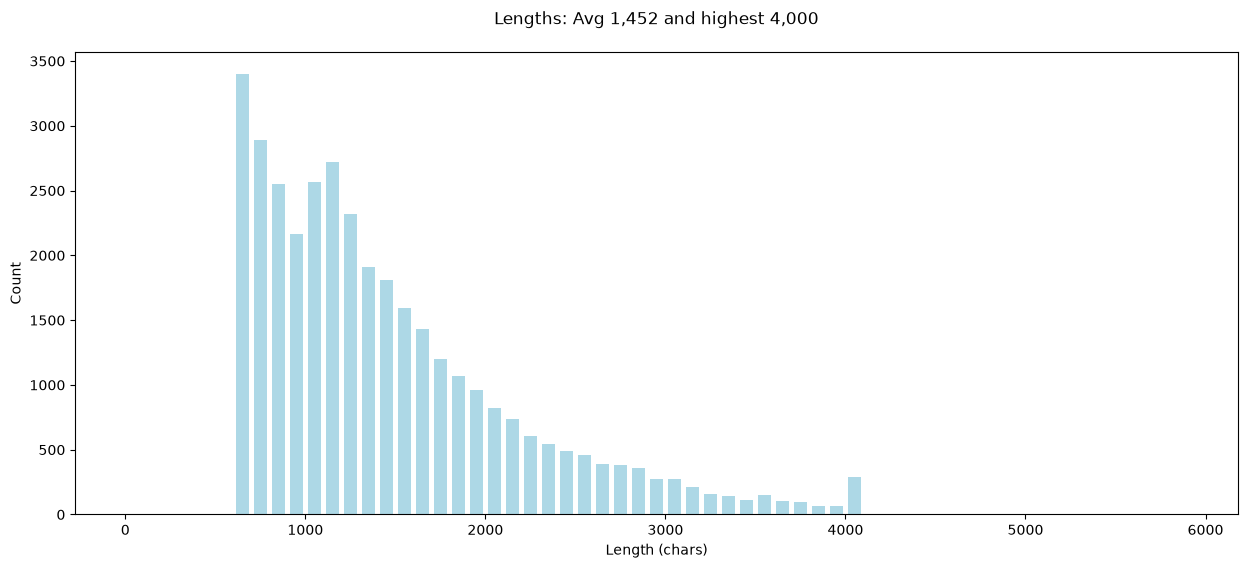

In [8]:
# 길이 분포 그래프 그리기 (한글로 하면 깨짐)

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [9]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

Polyester Dryer Vent Filters Replacement Part by Beaquicy Replacement for Better vent Indoor Dryer Vent Packs of 12
['✅【 AIR 】--- The polyester filters provide optimal air conditioning for your dryer and keep it away from polluted air. Because these parts will rate to trap fine lint and dust particles, protect your home from unwanted bacteria and other unfriendly dust particles and can be vacuumed clean or replaced when fully loaded with lint. so that the air in your room is cleaner than ever. While protecting your indoor quality, clothes can dry faster. It helps improve the indoor air quality.', '✅【HIGH-GRADE 】--- The package includes 12 x replacement polyester filters for bettervent.They are well-made from durable and high-grade polyester which can traps fine lint and dust particles, optimize the cleaning process and prolong lifetime. Each filter protects up to 5 dryer loads! For best results insert blue side facing towards dryer vent.', '✅【WIDE 】--- These polyester filters are desig

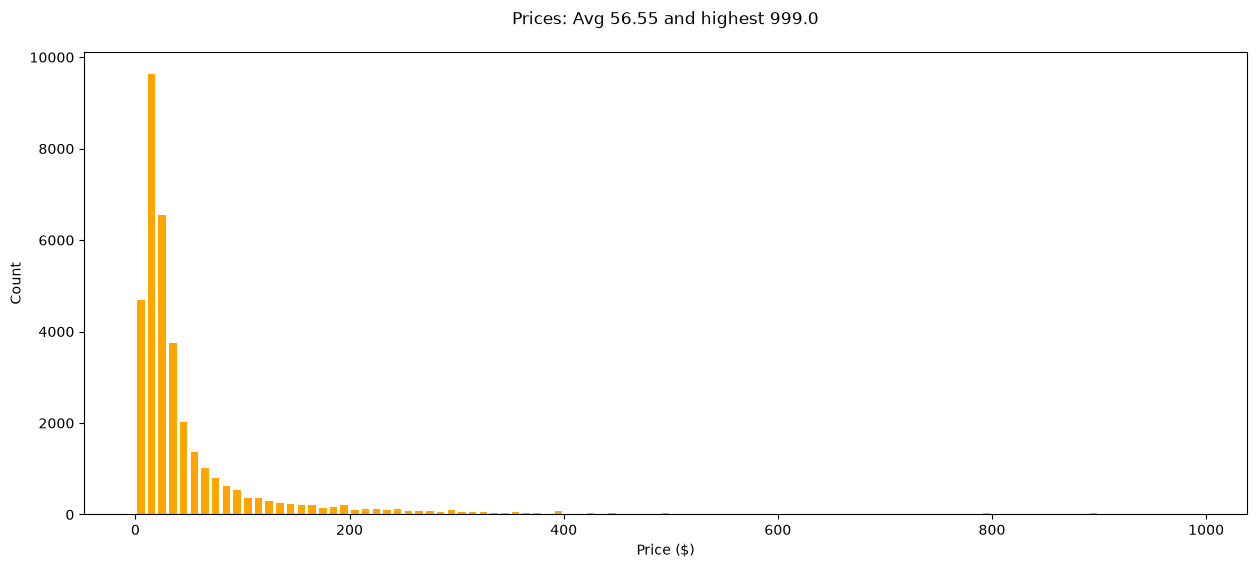

In [10]:
# 가격 분포 그래프 그리기
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [6]:
# ItemLoader: 지정한 카테고리의 데이터셋을 병렬로 내려받아 정제된 Item 리스트로 반환하는 로더

from pricer_ko.loaders import ItemLoader  # ItemLoader: 지정한 카테고리의 데이터셋을 병렬로 내려받아 정제된 Item 리스트로 반환하는 로더
loader = ItemLoader("Appliances")
items = loader.load()

Loading dataset Appliances


100%|██████████| 95/95 [00:07<00:00, 12.55it/s]


Completed Appliances with 35,307 datapoints in 0.2 mins


In [7]:
dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

In [8]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

Loading dataset Automotive


100%|██████████| 2004/2004 [01:12<00:00, 27.82it/s]


Completed Automotive with 974,469 datapoints in 1.4 mins
Loading dataset Electronics


100%|██████████| 1611/1611 [00:57<00:00, 28.15it/s]


Completed Electronics with 464,024 datapoints in 1.1 mins
Loading dataset Office_Products


...

Completed Toys_and_Games with 347,657 datapoints in 0.6 mins
Loading dataset Appliances


100%|██████████| 95/95 [00:08<00:00, 10.89it/s]


Completed Appliances with 35,307 datapoints in 0.2 mins
Loading dataset Musical_Instruments


100%|██████████| 214/214 [00:09<00:00, 22.14it/s] 


Completed Musical_Instruments with 68,855 datapoints in 0.2 mins


In [9]:
print(f"전체 합계 {len(items):,}개의 아이템")

전체 합계 2,933,577개의 아이템


In [10]:
items[1000]

<Coolant Temperature Sensor Compatible with Volvo V70 850 S70 960 C70 S90 V90 1997-1998 = $26.7>

In [11]:
random.seed(42)
random.shuffle(items)

seen = set()
# 이미 등장한 제목(title)이면 제외 (중복 제거)
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
# 이미 등장한 전체 텍스트(full)면 제외 (중복 제거)
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"중복 제거 후, {len(items):,}개의 아이템이 남았습니다")

  0%|          | 0/2933577 [00:00<?, ?it/s]

  0%|          | 0/2889429 [00:00<?, ?it/s]

중복 제거 후, 2,887,890개의 아이템이 남았습니다


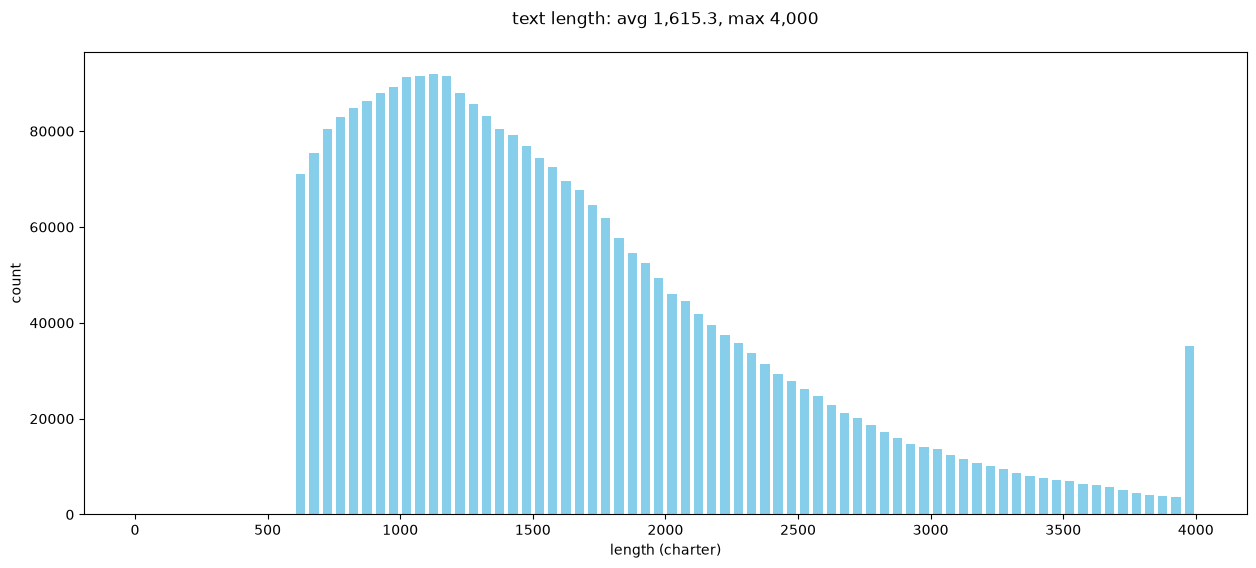

In [13]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"text length: avg {sum(lengths)/len(lengths):,.1f}, max {max(lengths):,}\n")
plt.xlabel('length (charter)')
plt.ylabel('count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


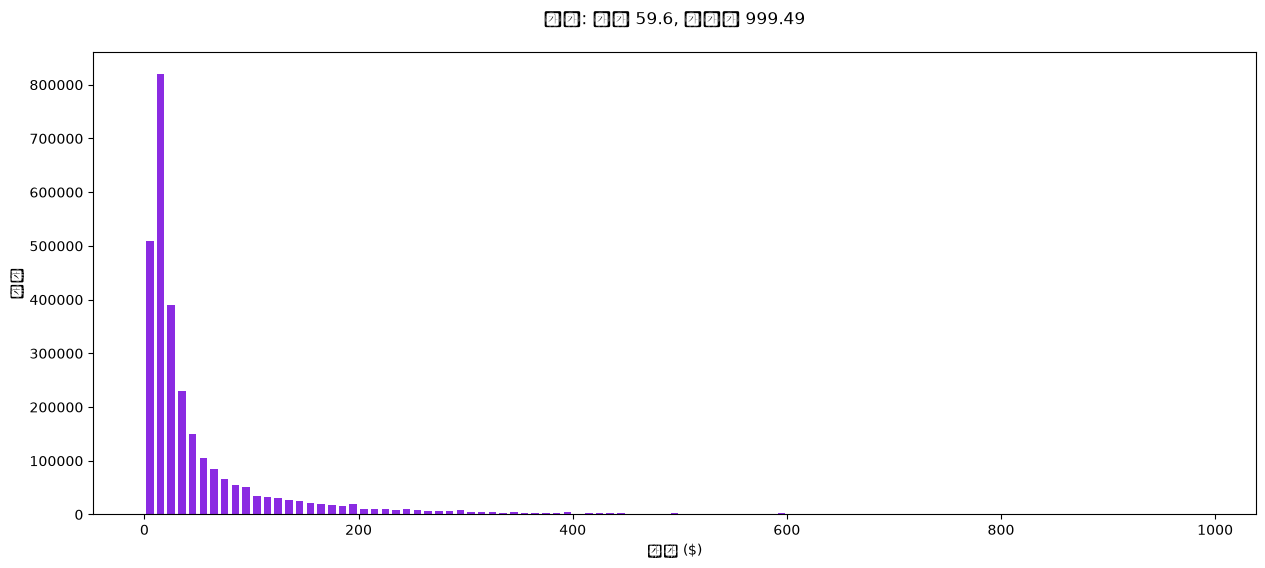

In [14]:
# 가격 분포 그래프 그리기

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"가격: 평균 {sum(prices)/len(prices):,.1f}, 최댓값 {max(prices):,}\n")
plt.xlabel('가격 ($)')
plt.ylabel('개수')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

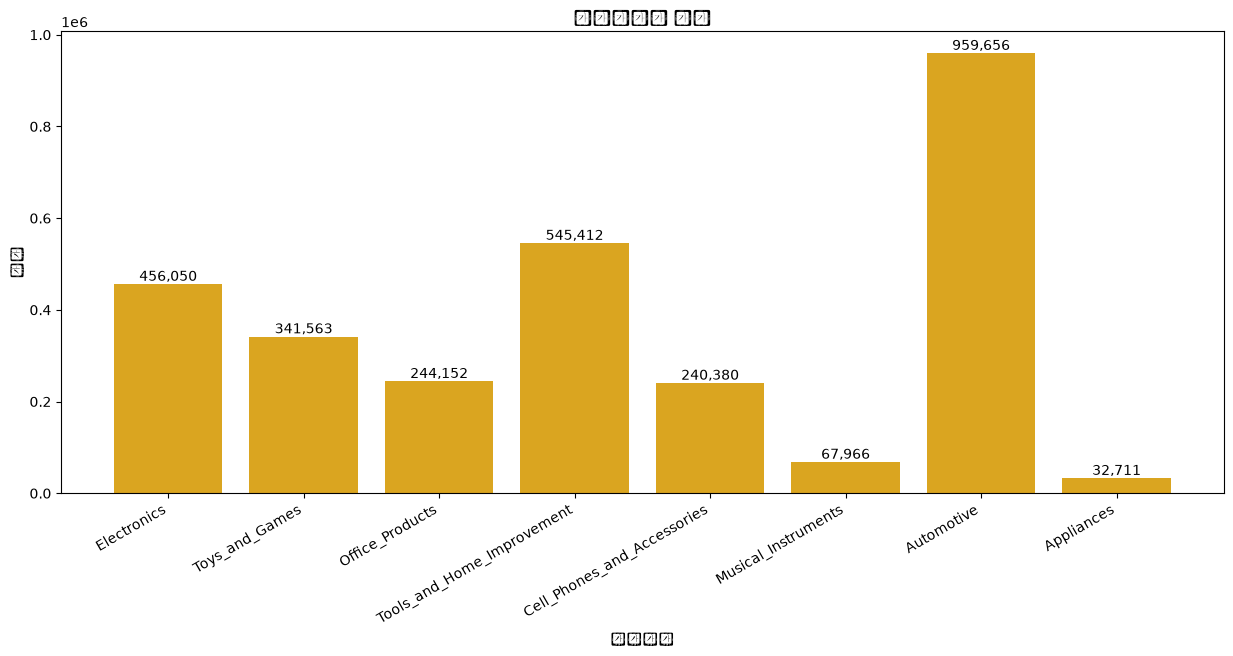

In [15]:
from collections import Counter
category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('카테고리별 개수')
plt.xlabel('카테고리')
plt.ylabel('개수')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [16]:
np.random.seed(42)

SIZE = 820_000  # 최종 샘플로 뽑을 아이템 개수

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])

# 가격을 0~1 사이로 정규화 (가중 샘플링에 쓸 가중치 계산용)
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

# 가격이 높을수록 뽑힐 확률이 커지도록 가중치 부여 (제곱을 취해 비싼 물건을 더 우대)
w = p**2
w[categories == "Tools_and_Home_Improvement"] *= 0.5  # 이 카테고리가 과대표집되지 않도록 가중치를 절반으로 낮춤
w[categories == "Automotive"] *= 0.05  # Automotive는 원래 수가 너무 많아 가중치를 크게 낮춤

w = w / w.sum()  # 확률 분포가 되도록 정규화
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)  # 가중치 기반 비복원 샘플링
sample = [items[i] for i in idx]


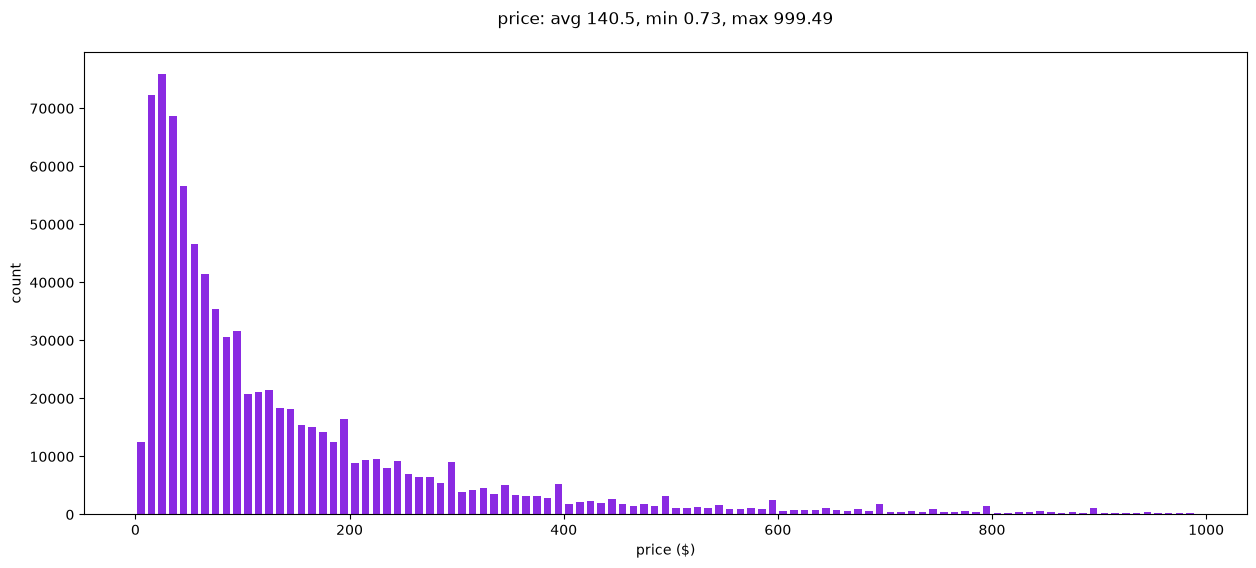

In [18]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"price: avg {sum(prices)/len(prices):,.1f}, min {min(prices):,}, max {max(prices):,}\n")
plt.xlabel('price ($)')
plt.ylabel('count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [19]:
# 만전을 기하기 위해, 최종 데이터셋을 위해 샘플을 한 번 더 섞습니다

random.seed(42)
random.shuffle(sample)

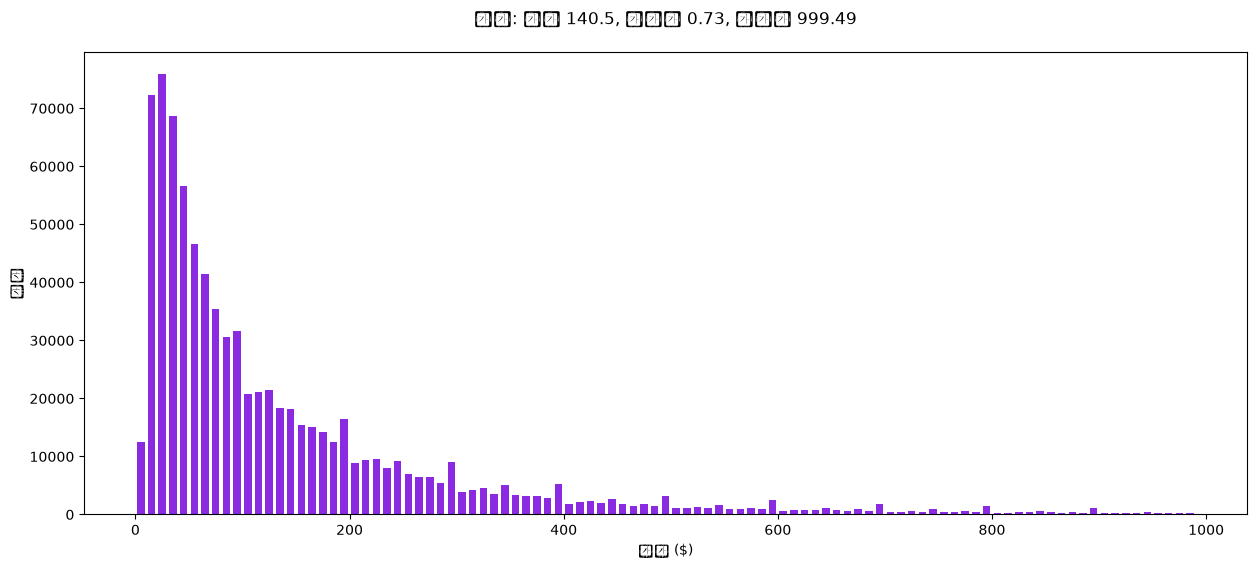

In [20]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"가격: 평균 {sum(prices)/len(prices):,.1f}, 최솟값 {min(prices):,}, 최댓값 {max(prices):,}\n")
plt.xlabel('가격 ($)')
plt.ylabel('개수')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

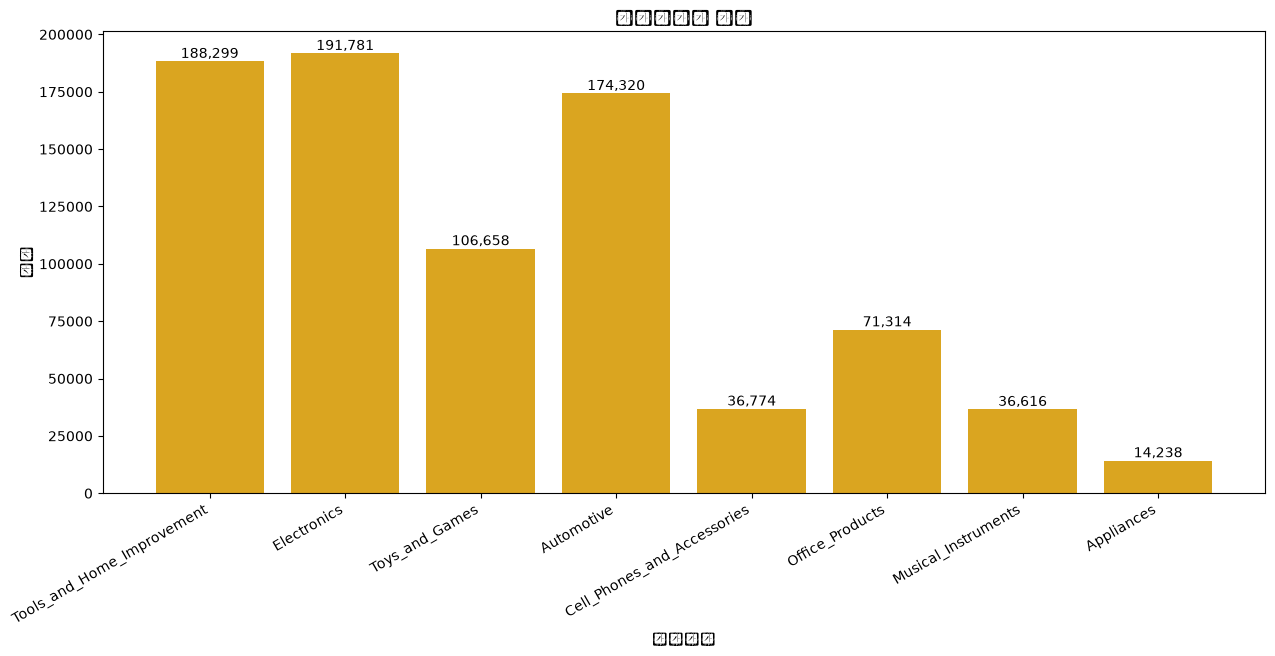

In [22]:
from collections import Counter
category_counts = Counter([item.category for item in sample])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# 카테고리별 막대 그래프
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('카테고리별 개수')
plt.xlabel('카테고리')
plt.ylabel('개수')

plt.xticks(rotation=30, ha='right')

# 각 막대 위에 값 라벨 추가
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# 그래프 표시
plt.show()

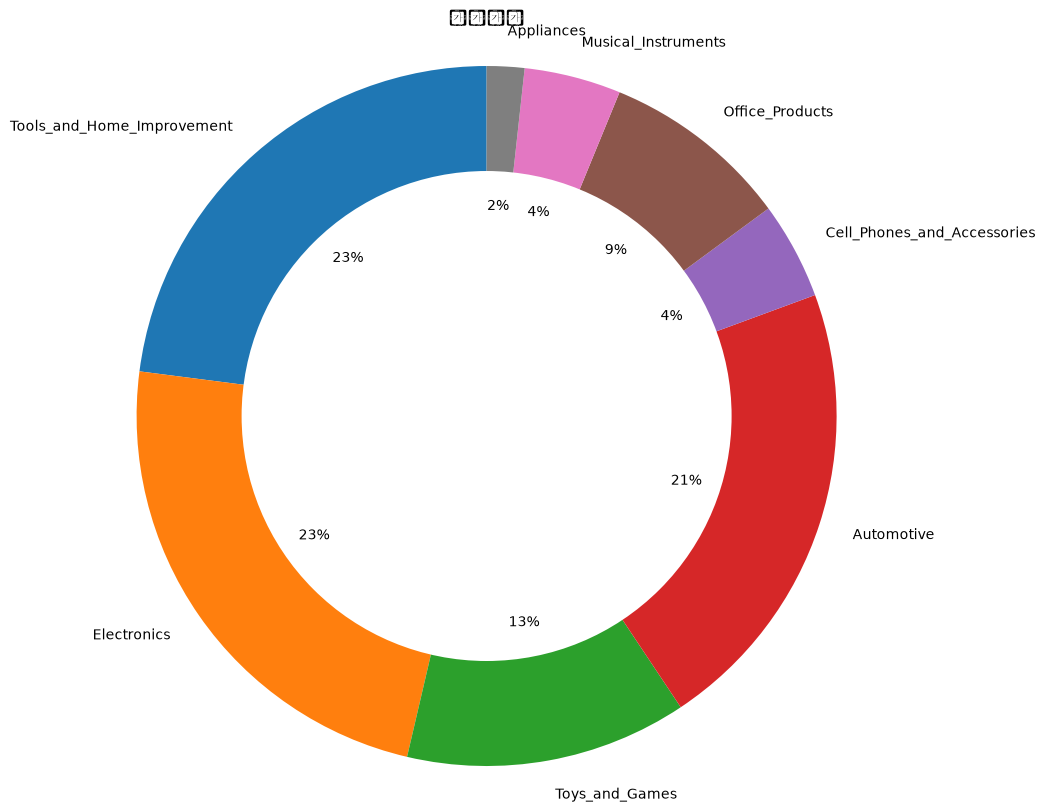

In [ ]:
# Automotive가 여전히 상위지만, 다소 개선되었습니다
# 다른 관점에서, 파이 차트도 살펴봅시다

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# 도넛 차트로 만들기 위해 중앙에 원 추가 (선택 사항)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('카테고리')

# 종횡비를 동일하게 하여 파이가 원형으로 그려지도록 함
plt.axis('equal')

plt.show()

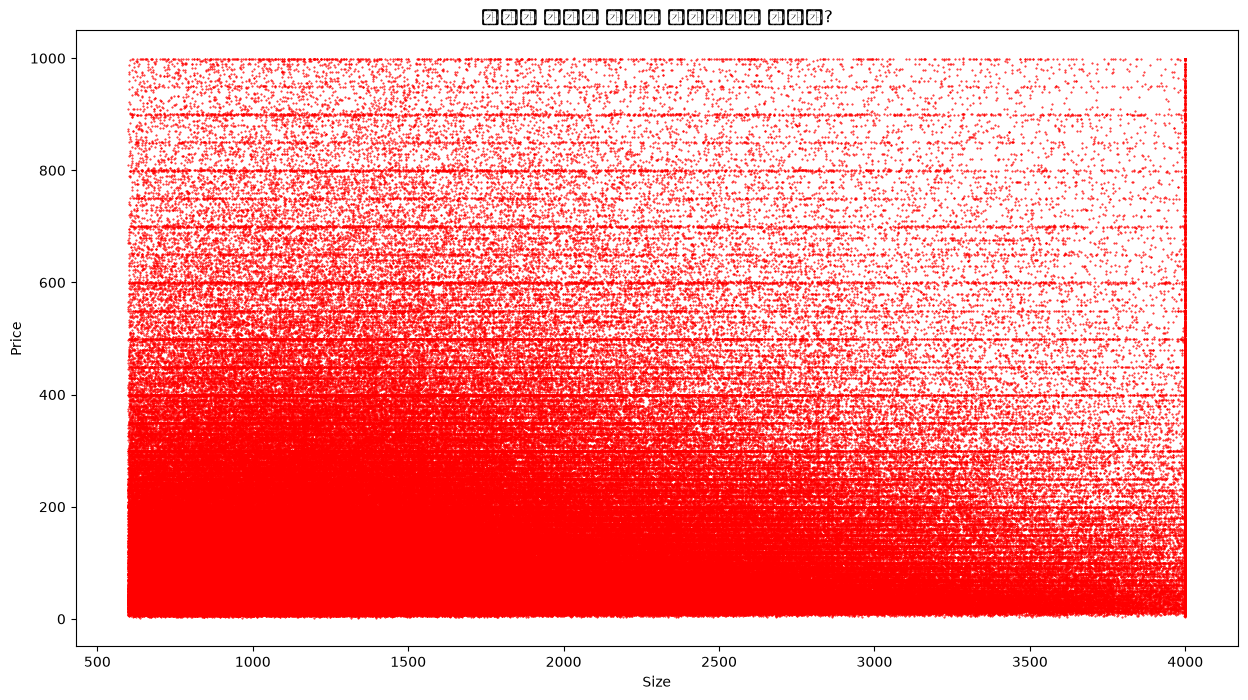

In [25]:
# 문자 수에 따라 가격이 어떻게 달라질까?

sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

# 산점도 생성
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# 라벨과 제목 추가
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('텍스트 길이와 단순한 상관관계가 있을까?')

# 그래프 표시
plt.show()

d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\STUDY\llm-core\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


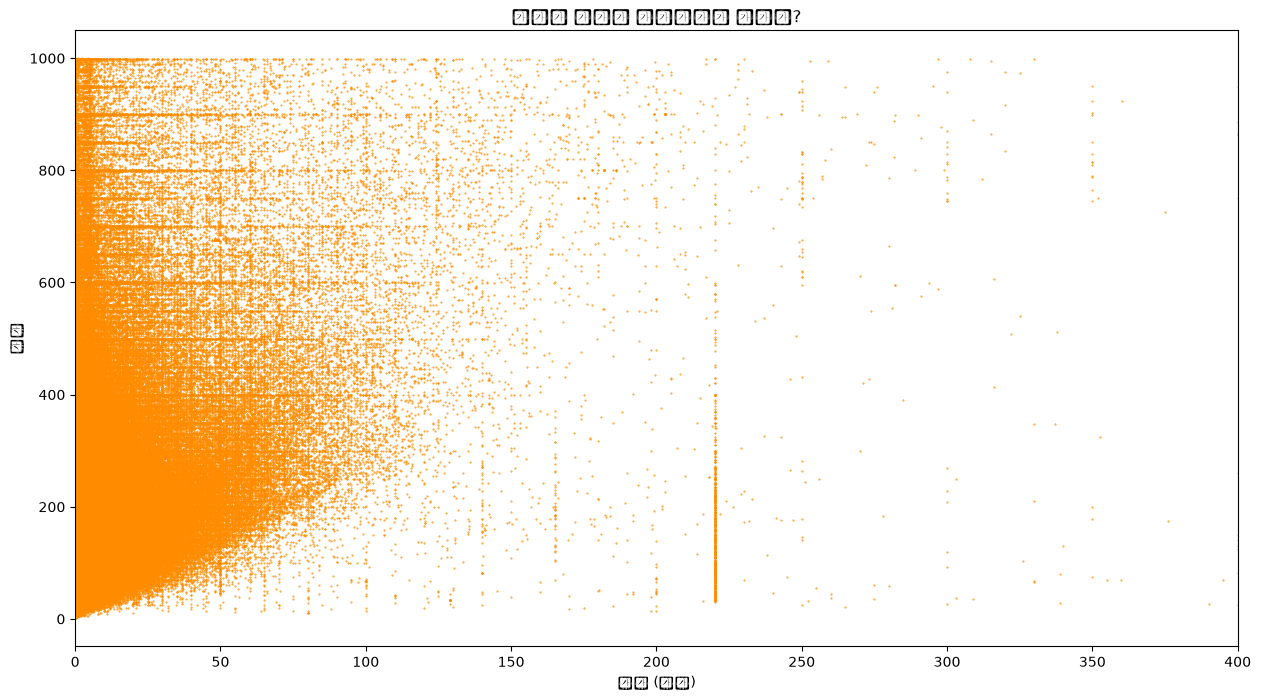

In [ ]:
# 무게에 따라 가격이 어떻게 달라질까?

ounces = [item.weight for item in sample]
prices = [item.price for item in sample]

# 산점도 생성
plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")

# 라벨과 제목 추가
plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?(무게와 단순한 상관관계가 있을까?)')

# 그래프 표시
plt.show()